<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
During peak sales periods such as holidays and seasonal promotions, ChicStyle experiences a sharp increase in customer orders and review volume. These reviews often contain critical feedback related to product quality, sizing, shipping delays, and overall customer experience. If feedback is not identified and acted on quickly, unresolved issues can escalate into customer dissatisfaction, negative brand perception, lost repeat business, and reduced loyalty. To protect revenue and brand reputation during high-demand periods, the business needs a scalable way to rapidly process large volumes of customer feedback and surface high-priority concerns for timely action.

### **Problem Statement**
Retailers struggle to keep up with large volumes of real-time customer reviews. Traditional NLP often misses nuanced or mixed feedback, causing delays in identifying urgent issues. Generative AI can accurately interpret sentiment and product-specific concerns, enabling faster, more effective responses to protect customer satisfaction and brand reputation.

### **Objective**
Build a Generative AI feedback system that uses prompt engineering techniques—Zero-Shot, Few-Shot, and Chain-of-Thought prompting—to:

Analyze and categorize sentiment in real time

Identify which product or service each feedback refers to

Summarize insights by product category and urgency level

Automatically send short, personalized messages to customers, such as:

Thanking them for positive feedback

Acknowledging neutral comments

Apologizing for negative experiences and informing them a team member will follow up

Generate concise, actionable reports for retail teams

This intelligent system will help retailers quickly act on customer issues, improve product quality faster, and enhance customer satisfaction—transforming massive, unstructured feedback into meaningful, real-time business intelligence.


### **Dataset Used for the Notebook**
This analysis uses the “Women's E-Commerce Clothing Reviews” dataset. The key columns are:

Clothing.ID – A unique identifier for each clothing item

Age – Age of the reviewer (positive integer)

Title – Title of the review (string)

Review.Text – Main body of the customer’s review (string)

Rating – Product score given by the customer, from 1 (worst) to 5 (best) (positive ordinal integer)

Recommended.IND – Binary indicator of whether the customer recommends the product (1 = recommended, 0 = not recommended)

Positive.Feedback.Count – Number of other customers who found the review helpful (positive integer)

Division.Name – High-level division of the product (categorical)

Department.Name – Specific department of the product (categorical)

Class.Name – Specific class of the product (categorical)

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [ ]:
# Install the required libraries for the project
!pip install pandas matplotlib seaborn
!pip install -q -U google-genai
!pip install openai
!pip install wordcloud
!pip install plotly

**Note:**

After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.


In [4]:
# Importing the necessary libraries
# Mandatory: Run this AFTER restarting the runtime following the installation step.
# --- Core Utilities ---
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

# --- Data Handling ---
import pandas as pd
from google.colab import userdata

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- Progress Bar ---
from tqdm import tqdm

# --- OpenAI Client ---
import openai

# Set global plot style
sns.set_style("whitegrid")

### **Data Loading**
### Loading and Understanding the Data


In [5]:
# load in the csv file from github repository
raw_github_url = "https://raw.githubusercontent.com/mikejoe144/MIT_Course_Capstone_Project/main/Dataset%20-%20Real-Time%20Retail%20Feedback%20Intelligence.csv" # You will need to fill this in with the actual URL

try:
    data = pd.read_csv(raw_github_url,sep=';')
    print("CSV file loaded successfully!")
except Exception as e:
    print(f"Error loading CSV file: {e}")
    print("Please ensure the URL is correct and points to a raw CSV file.")

CSV file loaded successfully!


In [6]:
# Copying data to another variable to avoid any changes to original data
df = data.copy()

### **Data Overview**

In [7]:
df.head()


,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### **Sanity checks**

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review.Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None


Checking for missing values

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

Title                      3810
Review.Text                 845
Division.Name                14
Department.Name              14
Class.Name                   14
Unnamed: 0                    0
Clothing.ID                   0
Age                           0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
dtype: int64


Checking for dulicate rows

In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
display(df.describe(include='all'))

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11743.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,1.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5872.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11743.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17614.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

Because we need the review text to build our model to be able to respond to feedback. we will need to drop the records which don't have review text. this is only 845 out of 23,485 rows (~3.6%) which is a small percent and safe to drop.

In [ ]:
#remove null review records
df = df.dropna(subset=['Review.Text'])

In [ ]:
#check null counts now
print(df.isnull().sum().sort_values(ascending=False))

Title                      2966
Division.Name                13
Department.Name              13
Class.Name                   13
Unnamed: 0                    0
Clothing.ID                   0
Age                           0
Review.Text                   0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
dtype: int64


this should be fine for null values now

from earlier it looked like Unnamed:0 was just a row number, we won't need that and will remove it for cleanliness

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

**What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?**

In [ ]:
# Selecting numerical columns and checking the summary statistics
num_cols = df.select_dtypes('number').columns

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Clothing.ID,22641.0,919.332362,202.266874,1.0,861.0,936.0,1078.0,1205.0
Age,22641.0,43.280376,12.326980,18.0,34.0,41.0,52.0,99.0
Rating,22641.0,4.183561,1.115762,1.0,4.0,5.0,5.0,5.0
Recommended.IND,22641.0,0.818868,0.385136,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,22641.0,2.630582,5.786164,0.0,0.0,1.0,3.0,122.0


**Observations:**


The average age of shoppers is 43, the majority being between 34 and 52.

The average rating is good at a 4.2, with most ratings being either 4 or 5.

Most shoppers (81%) would recommend the items they bought.

The average number of other customers who find the feedback helpful is around 3. there are some outlighers, the max being 122, so some reviews may go viral or highly influential



**How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?**

In [ ]:
categorical_cols = ['Division.Name', 'Department.Name', 'Class.Name']

#see the values names in each field
unique_values = {col: df[col].dropna().unique().tolist() for col in categorical_cols}

for col, values in unique_values.items():
    print(f"{col}: {values}\n")

Division.Name: ['Initmates', 'General', 'General Petite']

Department.Name: ['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']

Class.Name: ['Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters', 'Skirts', 'Fine gauge', 'Sleep', 'Jackets', 'Swim', 'Trend', 'Jeans', 'Legwear', 'Shorts', 'Layering', 'Casual bottoms', 'Chemises']



In [ ]:
# Number of unique values for each
df[categorical_cols].nunique()

,0
Division.Name,3
Department.Name,6
Class.Name,20


In [ ]:
# Group by Department and get unique Class names
dept_class_mapping = df.groupby('Department.Name')['Class.Name'].unique()

# Convert to lists and display
for dept, classes in dept_class_mapping.items():
    print(f"{dept}: {classes.tolist()}")

Bottoms: ['Pants', 'Skirts', 'Jeans', 'Shorts', 'Casual bottoms']
Dresses: ['Dresses']
Intimate: ['Intimates', 'Lounge', 'Sleep', 'Swim', 'Legwear', 'Layering', 'Chemises']
Jackets: ['Outerwear', 'Jackets']
Tops: ['Blouses', 'Knits', 'Sweaters', 'Fine gauge']
Trend: ['Trend']


In [ ]:
# Group by Division and get unique Departments
division_dept_mapping = df.groupby('Division.Name')['Department.Name'].unique()

# Display as lists
for division, departments in division_dept_mapping.items():
    print(f"{division}: {departments.tolist()}")

General: ['Dresses', 'Tops', 'Bottoms', 'Jackets', 'Trend']
General Petite: ['Bottoms', 'Tops', 'Dresses', 'Intimate', 'Jackets', 'Trend']
Initmates: ['Intimate']


There are 3 unique divisions names, 6 unique department names,and 20 unique class names.

the 6 departments contains the following class items...

Bottoms: Pants, Skirts, Jeans, Shorts, Casual bottoms

Dresses: Dresses

Intimate: Intimates, Lounge, Sleep, Swim, Legwear, Layering, Chemises

Jackets: Outerwear, Jackets

Tops: Blouses, Knits, Sweaters, Fine gauge

Trend: Trend

**What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?**

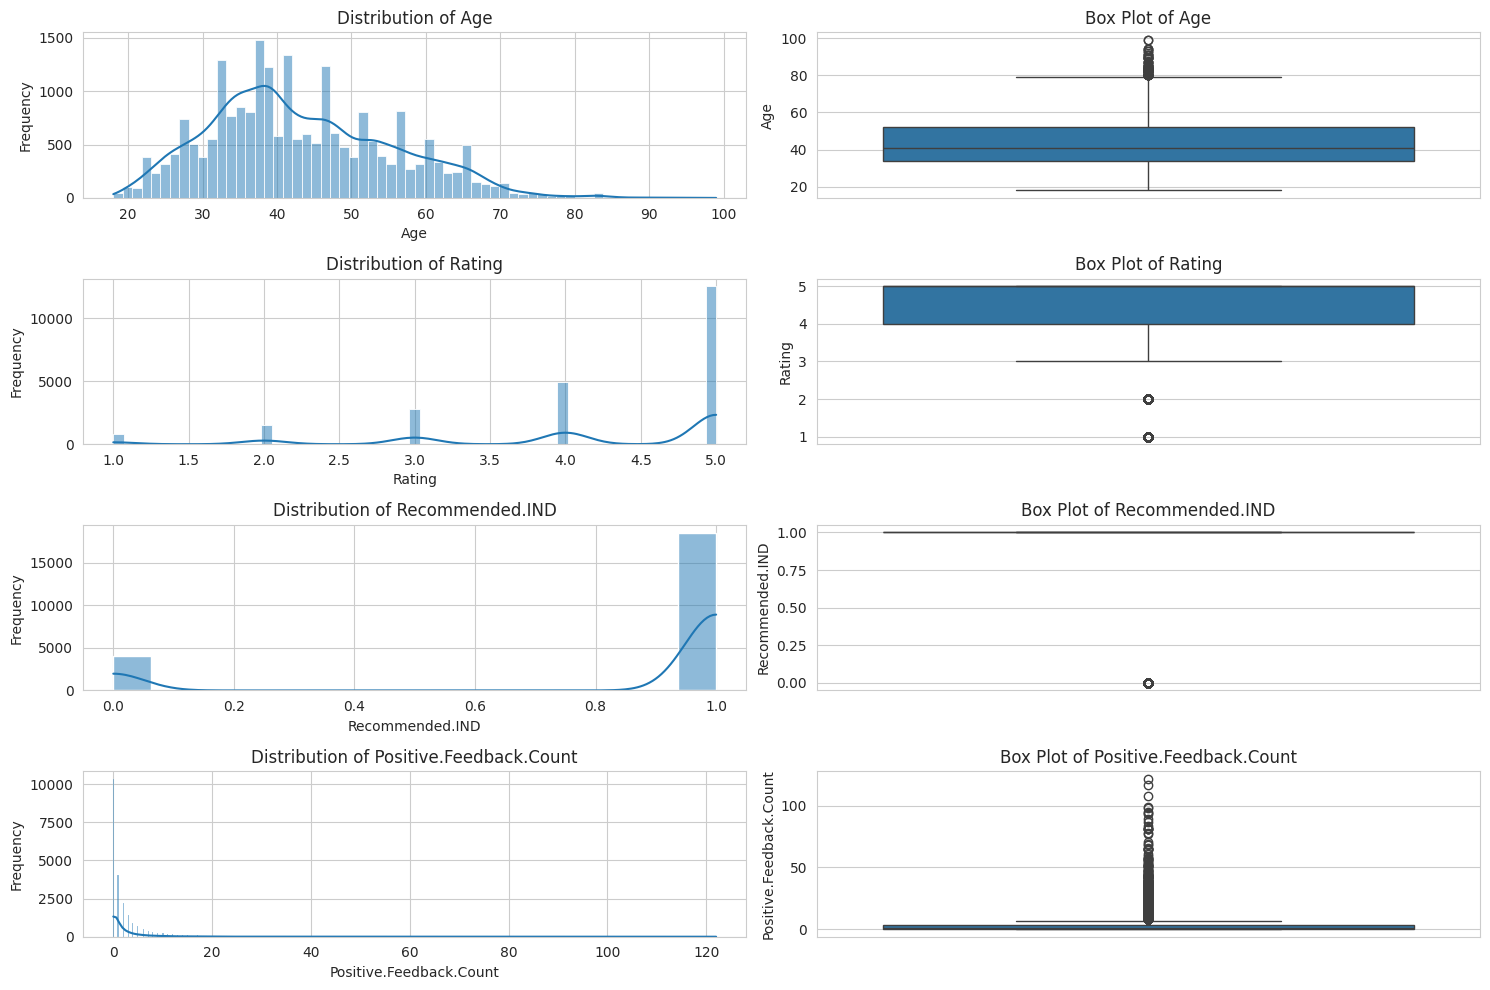

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Select numerical columns excluding 'Clothind ID'
num_cols_for_hist = df.select_dtypes(include=np.number).columns.tolist()
if 'Clothing.ID' in num_cols_for_hist:
    num_cols_for_hist.remove('Clothing.ID')


# Loop through the selected numerical columns and plot histograms and boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols_for_hist):
    plt.subplot(len(num_cols_for_hist), 2, i*2 + 1) # Histogram
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(len(num_cols_for_hist), 2, i*2 + 2) # Boxplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Observations:**

The product feedback appears to be left skewed. most reviews are positive. to prevent overfitting to positive reviews later when building out the model, we should include some negative reviews in our few-shot prompt later.

**Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?**

In [ ]:
# Group by Department and calculate average rating
dept_avg_rating = df.groupby('Department.Name')['Rating'].mean().reset_index()
dept_avg_rating.rename(columns={'Rating':'Average_Rating'}, inplace=True)
dept_avg_rating

,Department.Name,Average_Rating
0,Bottoms,4.278809
1,Dresses,4.138812
2,Intimate,4.271022
3,Jackets,4.254491
4,Tops,4.157743
5,Trend,3.838983


**Observation**

it appears that the trend department has the worst average ratings, and that bottoms has the highest average ratings. we may need to address the feedback from purchases from the Trend department faster to prevent customer disatisfaction.

In [ ]:
# Group by Department and Class, calculate mean rating
class_avg_rating = df.groupby(['Department.Name', 'Class.Name'])['Rating'].mean().reset_index()

# Optional: rename column for clarity
class_avg_rating.rename(columns={'Rating':'Average_Rating'}, inplace=True)
class_avg_rating.head()

,Department.Name,Class.Name,Average_Rating
0,Bottoms,Casual bottoms,4.000000
1,Bottoms,Jeans,4.347826
2,Bottoms,Pants,4.261481
3,Bottoms,Shorts,4.253289
4,Bottoms,Skirts,4.229236


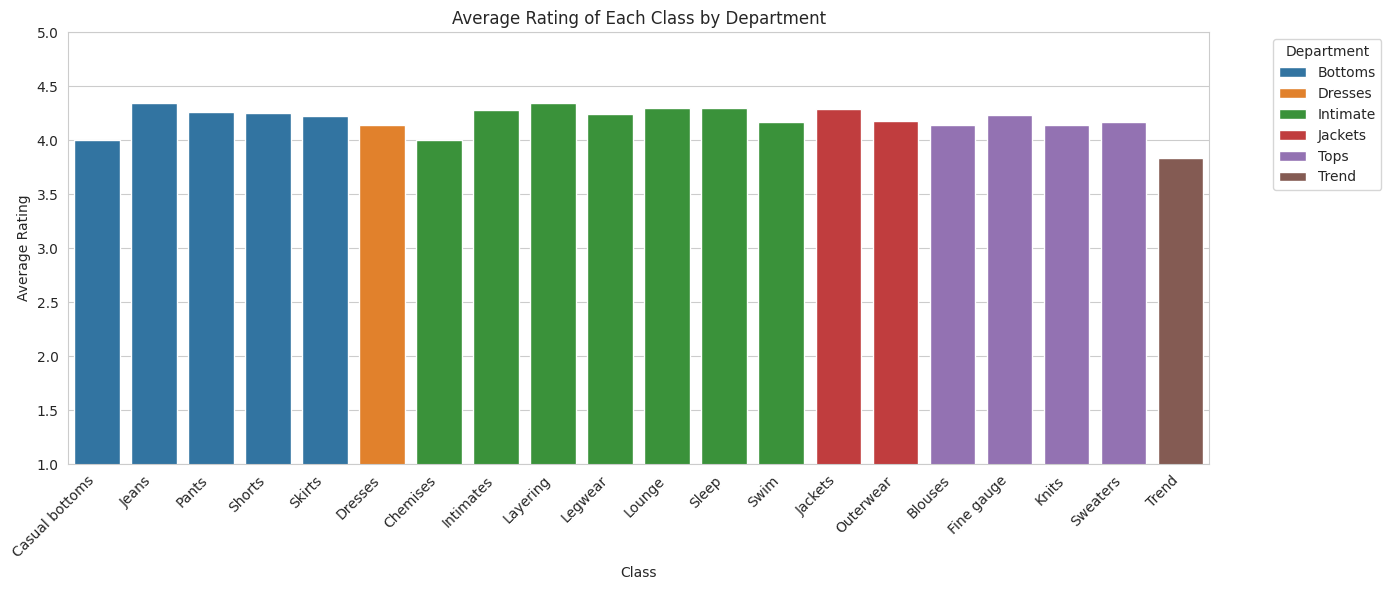

In [ ]:
plt.figure(figsize=(14,6))

# Bar plot: Class average rating with department as hue
sns.barplot(
    x='Class.Name',
    y='Average_Rating',
    hue='Department.Name',
    data=class_avg_rating
)

plt.title('Average Rating of Each Class by Department')
plt.xlabel('Class')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(1,5)  # Ratings are between 1 and 5
plt.tight_layout()
plt.show()

we already knew trend had a low average rating, but from this graph we see that casual bottoms and chemises also have low average ratings. jeans and layering have the 2 highest average ratings it appears.

**What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?**

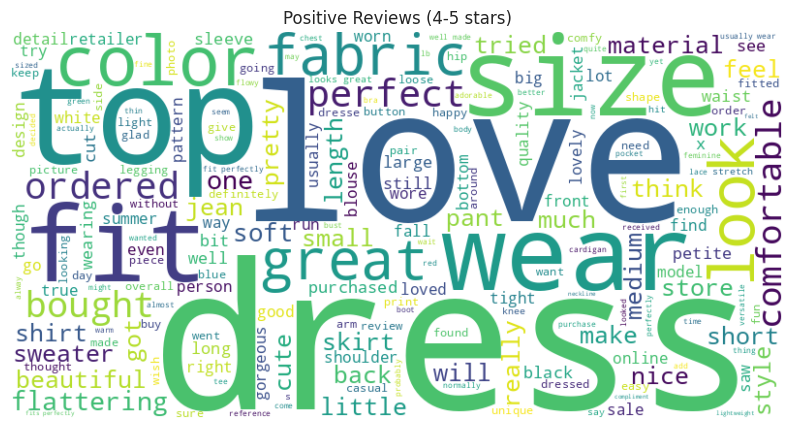

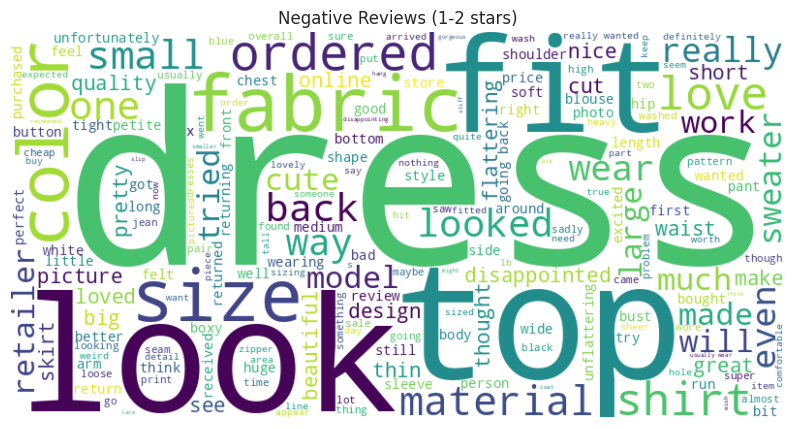

In [ ]:
!pip install wordcloud matplotlib
# Positive reviews (4-5 stars)
positive_reviews = df[df['Rating'].isin([4,5])]['Review.Text'].dropna()

# Negative reviews (1-2 stars)
negative_reviews = df[df['Rating'].isin([1,2])]['Review.Text'].dropna()

# Combine all reviews into a single string for word cloud
positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive reviews word cloud
plt.figure(figsize=(10,6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (4-5 stars)')
plt.show()

# Negative reviews word cloud
plt.figure(figsize=(10,6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews (1-2 stars)')
plt.show()

**Observations:**

dresses and tops appear in both word clouds, maybe those have the most contoversial opinions either people love or hate it. A lot of the same words show up in both word clouds like "fabric", "fit", "size", "look", "color" . these are probably the most common characteristics of the clothing people base their opinions on.

let's try creating word clouds of the negative and positive words to try and get some further insights

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


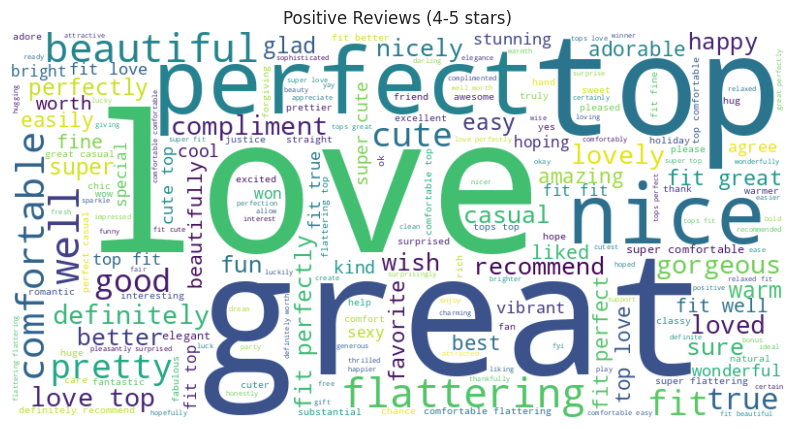

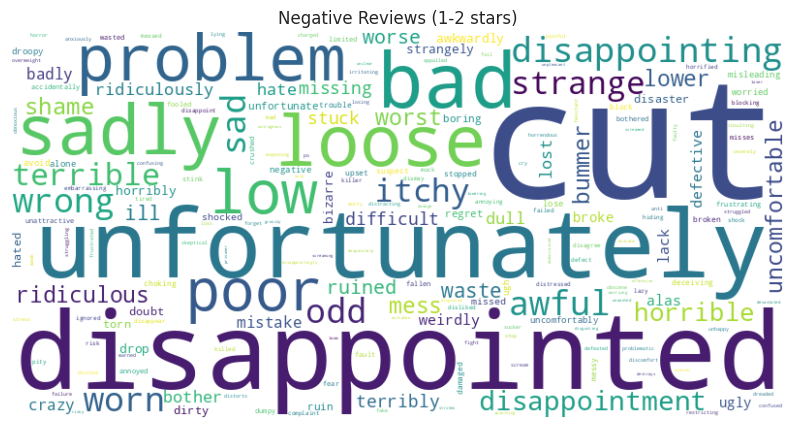

In [ ]:
# Install required libraries
!pip install nltk wordcloud matplotlib

# Import libraries
import pandas as pd
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download VADER lexicon
nltk.download('vader_lexicon')

# Load your data (adjust the path if needed)
# df = pd.read_csv('your_file.csv')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to filter words by sentiment
def sentiment_words(text, sentiment='positive'):
    words = re.findall(r'\b\w+\b', text.lower())  # tokenize
    filtered = []
    for word in words:
        score = sia.polarity_scores(word)['compound']
        if sentiment == 'positive' and score > 0.2:
            filtered.append(word)
        elif sentiment == 'negative' and score < -0.2:
            filtered.append(word)
    return " ".join(filtered)

# Combine review text by rating
positive_text = " ".join(df[df['Rating'].isin([4,5])]['Review.Text'].dropna())
negative_text = " ".join(df[df['Rating'].isin([1,2])]['Review.Text'].dropna())

# Extract sentiment-focused words
positive_filtered = sentiment_words(positive_text, sentiment='positive')
negative_filtered = sentiment_words(negative_text, sentiment='negative')

# Generate word cloud for positive reviews
plt.figure(figsize=(10,6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_filtered)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (4-5 stars)')
plt.show()

# Generate word cloud for negative reviews
plt.figure(figsize=(10,6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_filtered)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews (1-2 stars)')
plt.show()

**Observations:**

some of the popular words in the positive reviews are "flattering" and "comfertable".

some of the popular words in the negative reviews are "loose", "cut", "itchy", dissapointment"

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [8]:
# -----------------------------
# Setting up the Gemini Client (Colab-only)
# -----------------------------

from google.colab import userdata   # Colab helper to read secrets
from openai import OpenAI            # OpenAI-compatible client for Gemini

# Read the Gemini API key from Colab Secrets (secret name must match exactly)
gemini_api_key = userdata.get("OPENAI_API_KEY")   # set this secret in Colab as described above

# Instantiate the OpenAI-compatible client pointing to Google's Generative Language endpoint
client = OpenAI(
    api_key=gemini_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

print("Gemini client created. You can now use `client` to call embeddings and chat endpoints.")


Gemini client created. You can now use `client` to call embeddings and chat endpoints.


In [9]:

# List available models
print("Available Models (sample):")
models = client.models.list()
model_ids = [m.id for m in models.data]
print(model_ids[:10], "\n")

''' This uses up usage, don't use again

# 2. Embedding test
print("Embedding test (gemini-embedding-001)...")
emb_resp = client.embeddings.create(
    model="gemini-embedding-001",
    input="This is a test embedding."
)
emb_vector = emb_resp.data[0].embedding
print("Embedding generated. Vector length:", len(emb_vector), "\n")



# 3. Chat completion test
print("Chat completion test (gemini-2.5-flash)...")
chat_resp = client.chat.completions.create(
    model="gemini-2.5-flash",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Explain to me how AI works in one short sentence."}
    ],
)

# Print the assistant reply text
assistant_text = chat_resp.choices[0].message.content
print("Assistant reply:\n", assistant_text, "\n")

print("=== Sanity Check Completed ===")
'''

Available Models (sample):
['gpt-4-0613', 'gpt-4', 'gpt-3.5-turbo', 'gpt-5.4-mini', 'gpt-5.4', 'gpt-5.4-nano-2026-03-17', 'gpt-5.4-nano', 'gpt-5.4-mini-2026-03-17', 'davinci-002', 'babbage-002'] 



' This uses up usage, don\'t use again\n\n# 2. Embedding test\nprint("Embedding test (gemini-embedding-001)...")\nemb_resp = client.embeddings.create(\n    model="gemini-embedding-001",\n    input="This is a test embedding."\n)\nemb_vector = emb_resp.data[0].embedding\nprint("Embedding generated. Vector length:", len(emb_vector), "\n")\n\n\n\n# 3. Chat completion test\nprint("Chat completion test (gemini-2.5-flash)...")\nchat_resp = client.chat.completions.create(\n    model="gemini-2.5-flash",\n    messages=[\n        {"role": "system", "content": "You are a helpful assistant."},\n        {"role": "user", "content": "Explain to me how AI works in one short sentence."}\n    ],\n)\n\n# Print the assistant reply text\nassistant_text = chat_resp.choices[0].message.content\nprint("Assistant reply:\n", assistant_text, "\n")\n\nprint("=== Sanity Check Completed ===")\n'

In [10]:
#Define which model to use
model='gpt-4'

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [40]:
#limit sample to 5 reivews for testing
sample_df = df.sample(n=2, random_state=67)
sample_df.head()


,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
19605,19606,479,69,Ironing - ugh!,I am somewhere between a 24 and a 25 (i have n...,3,1,2,General,Bottoms,Shorts
1328,1329,865,53,"Soft, subtle loveliness",This a lovely piece. you have to see it close ...,5,1,0,General,Tops,Knits


In [15]:
import re
#define the judge
# This evaluates whether zero-shot output is good
def judge_output(review_text, model_output):

    judge_prompt = f"""
    You are evaluating retail feedback analysis produced by an AI system.

    Evaluate the output on these five dimensions:

    1. Category Accuracy
    2. Sentiment Accuracy
    3. Urgency Accuracy
    4. Personalized Message Quality
    5. Retail Insight Value


    Assign each dimension a score between 0 and 1:
    - 0 = incorrect / poor
    - 1 = excellent
    - decimals allowed (example: 0.75)

    Customer Review:
    {review_text}

    Model Output:
    {model_output}

    Return exactly in this format:

    Category Accuracy: X.XX
    Sentiment Accuracy: X.XX
    Summary Quality: X.XX
    Personalized Message Quality: X.XX
    Retail Insight Value: X.XX
    Overall Score: X.XX

    """

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": judge_prompt}
        ],
        temperature=0
    )

    result = response.choices[0].message.content

    # Extract overall score using regex
    match = re.search(r'Overall Score:\s*([0-9.]+)', result)

    if match:
        overall_score = float(match.group(1))
    else:
        overall_score = None

    return result, overall_score

In [23]:
 prompt = f"""
    Analyze this retail customer review and provide the following information. Fill in each field with actual content from the review.

  Category:
  Sentiment:
  Urgency:
  Personalized Message to the customer:
  Retail Insight:


    """

In [24]:
#define zeroshot review
def zero_shot_review(review_text, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": f"Customer Review:\n{review_text}"}
        ],
        temperature=0
    )

    text = response.choices[0].message.content

    # Empty dictionary for structured output
    out = {
        "Category": "",
        "Sentiment": "",
        "Urgency": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    # Parse line by line
    for line in text.splitlines():
        if ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower()
            val = val.strip()

            if key.startswith("category"):
                out["Category"] = val
            elif key.startswith("sentiment"):
                out["Sentiment"] = val
            elif key.startswith("urgency"):
                out["Urgency"] = val
            elif "personal" in key:
                out["Personalized_Message"] = val
            elif "insight" in key:
                out["Retail_Insight"] = val

    return out

In [41]:
#Apply zero-shot function to dataframe
results = sample_df['Review.Text'].apply(
    lambda x: zero_shot_review(x, prompt)
)

In [42]:
#Convert dictionary output into dataframe columns
results_df = pd.DataFrame(results.tolist(), index=sample_df.index)

# Rename columns to indicate source
results_df = results_df.rename(columns={
    'Category': 'V1_zero_shot_Category',
    'Sentiment': 'V1_zero_shot_Sentiment',
    'Urgency': 'V1_zero_shot_Urgency',
    'Personalized_Message': 'V1_zero_shot_Personalized_Message',
    'Retail_Insight': 'V1_zero_shot_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df, results_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V1_zero_shot_Category']}
Sentiment: {row['V1_zero_shot_Sentiment']}
Urgency: {row['V1_zero_shot_Urgency']}
Personalized Message: {row['V1_zero_shot_Personalized_Message']}
Retail Insight: {row['V1_zero_shot_Retail_Insight']}
""",
    axis=1
)


In [43]:
#Apply judge function
sample_df['V1_zero_shot_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V1_zero_shot_judge_text', 'V1_zero_shot_judge_score']] = pd.DataFrame(
    sample_df['V1_zero_shot_judge_result'].tolist(),
    index=sample_df.index
)

In [44]:
sample_df[['Review.Text',
           'V1_zero_shot_Category',
           'V1_zero_shot_Sentiment',
           'V1_zero_shot_Urgency',
           'V1_zero_shot_Personalized_Message',
           'V1_zero_shot_Retail_Insight',
           'V1_zero_shot_judge_score']]

,Review.Text,V1_zero_shot_Category,V1_zero_shot_Sentiment,V1_zero_shot_Urgency,V1_zero_shot_Personalized_Message,V1_zero_shot_Retail_Insight,V1_zero_shot_judge_score
19605,I am somewhere between a 24 and a 25 (i have n...,Clothing/Fit and Material,Positive,Low,"Hi there, we're thrilled to hear that you foun...",The customer appreciates the variety in sizes ...,0.76
1328,This a lovely piece. you have to see it close ...,Product Quality and Fit,Positive,Low,"Hi there, thank you for your wonderful review!...",The customer is satisfied with the product's q...,0.80


In [45]:
#average of the judge score for V1 zero shot prompt is
print("Average Judge Score zero shot V1:", round(sample_df['V1_zero_shot_judge_score'].mean(), 2))

Average Judge Score zero shot V1: 0.78


In [62]:
#create V2 prompt
prompt = """
You are a retail customer feedback analyst.

Analyze customer reviews and return structured business-ready output.

Instructions:
- Determine which product category the review refers to using this list:
  'Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear', 'Lounge', 'Sweaters',
  'Skirts', 'Fine gauge', 'Sleep', 'Jackets', 'Swim', 'Trend', 'Jeans', 'Legwear',
  'Shorts', 'Layering', 'Casual bottoms', 'Chemises'

- Identify sentiment as Positive, Neutral, or Negative.

- Generate a short personalized customer response:
    - Positive → thank customer
    - Neutral → acknowledge feedback
    - Negative → apologize and mention follow-up

- Provide one actionable Retail Insight in 1-2 sentences. Be specific and business-focused. Never leave it blank.

Retail insight must be specific and actionable.

Return exactly in this format and do not leave any field empty:

Category:
Sentiment:
Urgency:
Personalized Message:
Retail Insight:


"""

In [63]:
#Apply zero-shot function to dataframe for prompt V2
results = sample_df['Review.Text'].apply(
    lambda x: zero_shot_review(x, prompt)
)

In [64]:
#Convert dictionary output into dataframe columns
results_df = pd.DataFrame(results.tolist(), index=sample_df.index)

# Rename columns to indicate source
results_df = results_df.rename(columns={
    'Category': 'V2_zero_shot_Category',
    'Sentiment': 'V2_zero_shot_Sentiment',
    'Urgency': 'V2_zero_shot_Urgency',
    'Personalized_Message': 'V2_zero_shot_Personalized_Message',
    'Retail_Insight': 'V2_zero_shot_Retail_Insight'
})

#Join back to original dataframe
sample_df = pd.concat([sample_df, results_df], axis=1)

#Create one combined model output for judge
sample_df['model_output'] = sample_df.apply(
    lambda row: f"""
Category: {row['V2_zero_shot_Category']}
Sentiment: {row['V2_zero_shot_Sentiment']}
Urgency: {row['V2_zero_shot_Urgency']}
Personalized Message: {row['V2_zero_shot_Personalized_Message']}
Retail Insight: {row['V2_zero_shot_Retail_Insight']}
""",
    axis=1
)

In [66]:
#Apply judge function
sample_df['V2_zero_shot_judge_result'] = sample_df.apply(
    lambda row: judge_output(row['Review.Text'], row['model_output']),
    axis=1
)

#Split judge output into separate columns
sample_df[['V2_zero_shot_judge_text', 'V2_zero_shot_judge_score']] = pd.DataFrame(
    sample_df['V2_zero_shot_judge_result'].tolist(),
    index=sample_df.index
)

In [67]:
sample_df[['Review.Text',
           'V2_zero_shot_Category',
           'V2_zero_shot_Sentiment',
           'V2_zero_shot_Urgency',
           'V2_zero_shot_Personalized_Message',
           'V2_zero_shot_Retail_Insight',
           'V2_zero_shot_judge_score']]

,Review.Text,V2_zero_shot_Category,V2_zero_shot_Category,V2_zero_shot_Category,V2_zero_shot_Sentiment,V2_zero_shot_Sentiment,V2_zero_shot_Sentiment,V2_zero_shot_Urgency,V2_zero_shot_Urgency,V2_zero_shot_Urgency,V2_zero_shot_Personalized_Message,V2_zero_shot_Personalized_Message,V2_zero_shot_Personalized_Message,V2_zero_shot_Retail_Insight,V2_zero_shot_Retail_Insight,V2_zero_shot_Retail_Insight,V2_zero_shot_judge_score
19605,I am somewhere between a 24 and a 25 (i have n...,Jeans,Pants,Jeans,Positive,Positive,Positive,Low,Low,Low,Thank you for your positive feedback! We're gl...,Thank you for your positive feedback! We're gl...,We're thrilled to hear that you loved the blue...,,,Consider highlighting the stretchability and u...,0.94
1328,This a lovely piece. you have to see it close ...,Sweaters,Sweaters,Sweaters,Positive,Positive,Positive,Low,Low,Low,Thank you for your positive feedback! We're th...,Thank you for your kind words and detailed fee...,Thank you for your positive feedback! We're th...,,,The product is not showing up in the 'sweaters...,0.94


In [68]:
#average of the judge score for V2 zero shot prompt is
print("Average Judge Score zero shot V2:", round(sample_df['V2_zero_shot_judge_score'].mean(), 2))

Average Judge Score zero shot V2: 0.94


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

### **Observations and Insights**

## **Conclusion**